# Countdown distillation on Gemma 3 1B

`google/gemma-3-1b-it` is a compact student model and is a good fit for distillation. Here we follow the idea of the Kaggle `distillation-challenge-2026` competition to train this small LLM play Countdown: using a given set of numbers and basic operators (`+`, `-`, `*`, `/`), create an equation that hits a specific target number. Example:

* Numbers: `[75, 80, 90, 24]`
* Target: `61`
* Solution: `90 - 80 + 75 - 24 = 61`

We use verified `Qwen2.5-7B-Instruct` answers from Hugging Face as supervision, so the student learns directly from reasoning traces in text, `<think>`, and `<answer>` format.


## Installation

In [ ]:
!pip install -U transformers accelerate peft trl datasets huggingface-hub pandas matplotlib torch

## Imports and configuration

In [1]:
import os
import re
import json
import random
import subprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from tqdm.auto import tqdm
from datasets import load_dataset, Dataset
from transformers import AutoTokenizer, AutoModelForCausalLM, TrainerCallback
from huggingface_hub import login
from peft import LoraConfig, PeftModel
from trl import SFTTrainer, SFTConfig


login(token="YOUR_TOKEN")
hf_dataset_id = "HuggingFaceTB/Countdown-Task-GOLD"
verified_split_id = "verified_Qwen2.5-7B-Instruct"
student_model_id = "google/gemma-3-1b-it"

output_dir = "./gemma3_1b_countdown_reasoning_verified_10k"
submission_path = "./submission.csv"
hub_model_id = "pymlex/gemma3-1b-countdown-reasoning"

seed = 3407
train_limit = float("inf")

torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

bf16 = torch.cuda.is_available() and torch.cuda.is_bf16_supported()
fp16 = torch.cuda.is_available() and not bf16

device_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu"
vram_gb = 0.0

if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    vram_gb = props.total_memory / (1024 ** 3)

print(f"GPU: {device_name}")
print(f"VRAM: {vram_gb:.2f} GB")
print(f"bf16: {bf16}")
print(f"fp16: {fp16}")

GPU: NVIDIA GeForce RTX 5090
VRAM: 31.32 GB
bf16: True
fp16: False


## Dataset download and selection

The verified split already contains completed reasoning traces from `Qwen2.5-7B-Instruct`.
We keep only 10k examples to stay fast and focused.


In [2]:
dataset = load_dataset(hf_dataset_id, verified_split_id)
train_base = dataset["train"]

train_base = train_base.shuffle(seed=seed)
train_base = train_base.select(range(min(train_limit, len(train_base))))

print(train_base)
print(train_base.column_names)
print(train_base[0])

Dataset({
    features: ['target', 'nums', 'messages'],
    num_rows: 30441
})
['target', 'nums', 'messages']
{'target': 30, 'nums': [23, 25, 41, 69], 'messages': [{'content': 'You are a helpful assistant. You first think about the reasoning process in the mind and then provide the user with the answer.', 'role': 'system'}, {'content': 'Using the numbers [23, 25, 41, 69], create an equation that equals 30. You can use basic arithmetic operations (+, -, *, /) and each number can only be used once. Show your work in <think> </think> tags. And return the final equation and answer in <answer> </answer> tags, for example <answer> (1 + 2) / 3 = 1 </answer>.', 'role': 'user'}, {'content': "<think>\nTo solve this, I need to use the numbers 23, 25, 41, and 69 in a way that their combination equals 30 using basic arithmetic operations. Let's try different combinations:\n\n1. Trying to use 23 and 25 first: (23 + 25) / 41 = 48 / 41 ≠ 30\n2. Trying 23 and 69: (23 * 69) - 41 - 25 = 1587 - 41 - 25 = 

## Text building and length histogram

The student sees the same chat structure as the verified data, including the assistant reasoning trace.
The histogram is built from token lengths, since that is what controls the context budget directly.


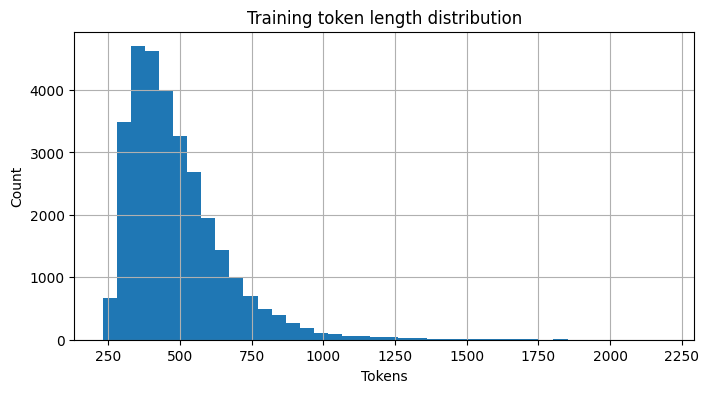

In [3]:
student_tokenizer = AutoTokenizer.from_pretrained(student_model_id)
if student_tokenizer.pad_token is None:
    student_tokenizer.pad_token = student_tokenizer.eos_token
student_tokenizer.padding_side = "left"

def make_student_text(example, tokenizer):
    return tokenizer.apply_chat_template(
        example["messages"],
        tokenize=False,
        add_generation_prompt=False
    )

student_rows = []

for example in train_base:
    text = make_student_text(example, student_tokenizer)
    student_rows.append({
        "text": text
    })

student_df = pd.DataFrame(student_rows)
student_df["char_len"] = student_df["text"].str.len()
student_df["token_len"] = student_df["text"].apply(
    lambda x: len(student_tokenizer(x, add_special_tokens=False)["input_ids"])
)

plt.figure(figsize=(8, 4))
plt.hist(student_df["token_len"], bins=40)
plt.title("Training token length distribution")
plt.xlabel("Tokens")
plt.ylabel("Count")
plt.grid(True)
plt.show()

In [4]:
print(student_df["token_len"].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]))

max_seq_length = 1024
student_df = student_df[student_df["token_len"] < 850].reset_index(drop=True)

print(f"Selected max_seq_length = {max_seq_length}")

count    30441.000000
mean       486.969416
std        176.814653
min        230.000000
50%        447.000000
75%        563.000000
90%        698.000000
95%        808.000000
99%       1115.600000
max       2196.000000
Name: token_len, dtype: float64
Selected max_seq_length = 1024


## Train / validation split

A small validation split is enough here because the data is synthetic and already verified.


In [5]:
dataset_all = Dataset.from_pandas(student_df[["text"]], preserve_index=False)
split_1 = dataset_all.train_test_split(test_size=0.05, seed=seed)

train_ds = split_1["train"]
val_ds = split_1["test"]

print(train_ds)
print(val_ds)

Dataset({
    features: ['text'],
    num_rows: 27809
})
Dataset({
    features: ['text'],
    num_rows: 1464
})


## Base model, LoRA, and training config

The model is loaded in bf16 when possible. We also use a GPU callback to monitor system resources.


In [6]:
student_model = AutoModelForCausalLM.from_pretrained(
    student_model_id,
    device_map="auto",
    torch_dtype=torch.bfloat16 if bf16 else torch.float16
)

student_model.config.use_cache = False
student_model.gradient_checkpointing_enable()

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/340 [00:00<?, ?it/s]

In [7]:
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj"
    ]
)

def gpu_status_line():
    if not torch.cuda.is_available():
        return "GPU=cpu"

    device_id = torch.cuda.current_device()
    raw = subprocess.check_output([
        "nvidia-smi",
        "--query-gpu=utilization.gpu,memory.used,memory.total",
        "--format=csv,noheader,nounits",
    ]).decode("utf-8").strip().splitlines()[device_id]

    gpu_util, mem_used, mem_total = [x.strip() for x in raw.split(",")]
    return f"GPU={gpu_util}% | VRAM={mem_used}/{mem_total} MB"


class TrainStatusCallback(TrainerCallback):
    def on_log(self, args, state, control, logs=None, **kwargs):
        if not logs:
            return

        if not torch.cuda.is_available():
            return

        loss = logs.get("loss", None)
        eval_loss = logs.get("eval_loss", None)

        msg = f"[STEP {state.global_step}] "

        if loss is not None:
            msg += f"loss={loss:.4f} | "

        if eval_loss is not None:
            msg += f"eval_loss={eval_loss:.4f} | "

        msg += gpu_status_line()
        print(msg)

In [8]:
def parse_answer(text):
    match = re.search(r"<answer>\s*(.*?)\s*</answer>", text, re.S)
    if match is None:
        return text.strip()
    return match.group(1).strip()

def split_prompt_and_target(text):
    prompt_text = re.split(r"<start_of_turn>model\s*\n", text, maxsplit=1)[0]
    match = re.search(r"equals\s+(-?\d+)\.", prompt_text)
    target = int(match.group(1))
    return prompt_text, target

def generate_student_batch_from_prompts(model, tokenizer, prompts, max_new_tokens=850):
    encodings = tokenizer(
        prompts,
        return_tensors="pt",
        padding=True
    ).to(model.device)

    print(
        f"Eval batch start | batch={len(prompts)} | "
        f"prompt_tokens={encodings['input_ids'].shape[1]} | {gpu_status_line()}"
    )

    with torch.inference_mode():
        generated = model.generate(
            **encodings,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.7,
            top_p=0.95,
            repetition_penalty=1.05,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id
        )

    prompt_lengths = encodings["attention_mask"].sum(dim=1).tolist()
    outputs = []

    for i, prompt_length in enumerate(prompt_lengths):
        completion_ids = generated[i, prompt_length:]
        completion = tokenizer.decode(completion_ids, skip_special_tokens=True).strip()
        outputs.append(completion)

    print(f"Eval batch done | {gpu_status_line()}")

    return outputs

class ValAccuracyCallback(TrainerCallback):
    def __init__(self, tokenizer, model, val_ds, sample_size=100, batch_size=32, max_new_tokens=850):
        self.tokenizer = tokenizer
        self.model = model
        self.sample_size = min(sample_size, len(val_ds))
        self.batch_size = batch_size
        self.max_new_tokens = max_new_tokens

        self.prompts = []
        self.targets = []
        self.history = []

        for text in val_ds["text"][:self.sample_size]:
            prompt_text, target = split_prompt_and_target(text)
            self.prompts.append(prompt_text)
            self.targets.append(target)

    def on_evaluate(self, args, state, control, **kwargs):
        was_training = self.model.training
        self.model.eval()
        self.tokenizer.padding_side = "left"

        predictions = []
        batch_prompts = []

        for prompt in self.prompts:
            batch_prompts.append(prompt)

            if len(batch_prompts) == self.batch_size:
                completions = generate_student_batch_from_prompts(
                    self.model,
                    self.tokenizer,
                    batch_prompts,
                    max_new_tokens=self.max_new_tokens
                )
                predictions.extend(completions)
                batch_prompts = []

        if len(batch_prompts) > 0:
            completions = generate_student_batch_from_prompts(
                self.model,
                self.tokenizer,
                batch_prompts,
                max_new_tokens=self.max_new_tokens
            )
            predictions.extend(completions)

        correct = 0

        for pred, target in zip(predictions, self.targets):
            expr = parse_answer(pred).strip().strip("\n")
            expr = expr.split("=")[0].strip()
            try:
                value = eval(expr)
            except:
                continue
            if value == target:
                correct += 1

        accuracy = correct / len(self.targets)
        self.history.append({
            "step": state.global_step,
            "val_accuracy": accuracy
        })

        print(f"[STEP {state.global_step}] val_accuracy={accuracy:.4f} ({correct}/{len(self.targets)})")

        if was_training:
            self.model.train()

In [9]:
training_args = SFTConfig(
    output_dir=output_dir,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=8,
    num_train_epochs=1,
    learning_rate=2e-4,
    warmup_steps=80,
    lr_scheduler_type="cosine",
    optim="adamw_torch",
    logging_strategy="steps",
    logging_steps=1,
    eval_strategy="steps",
    eval_steps=10,
    eval_on_start=True,
    save_strategy="steps",
    save_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    bf16=bf16,
    fp16=fp16,
    report_to="none",
    seed=seed,
    packing=False,
    dataset_text_field="text",
    max_length=max_seq_length,
)

trainer = SFTTrainer(
    model=student_model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds.select(range(100)),
    processing_class=student_tokenizer,
    peft_config=lora_config,
)

trainer.add_callback(TrainStatusCallback())
trainer.add_callback(
    ValAccuracyCallback(
        tokenizer=student_tokenizer,
        model=student_model,
        val_ds=val_ds,
        sample_size=100,
        batch_size=100,
        max_new_tokens=850
    )
)

Adding EOS to train dataset:   0%|          | 0/27809 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/27809 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/100 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/100 [00:00<?, ? examples/s]

## Training and saving

Training was performed with RTX 5090 (32 GB VRAM), CUDA 13.0, Ryzen 9 9950X, and 62 GB RAM.

In [10]:
train_result = trainer.train()
print(train_result)

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 1}.


Step,Training Loss,Validation Loss
0,No log,2.095372
10,1.787910,1.733860
20,1.129518,1.080528
30,0.643919,0.588919
40,0.458425,0.458231
50,0.439205,0.406163
60,0.365631,0.359136
70,0.358141,0.336466
80,0.365013,0.322306
90,0.350085,0.315377


[STEP 0] eval_loss=2.0954 | GPU=93% | VRAM=30701/32607 MB
Eval batch start | batch=100 | prompt_tokens=128 | GPU=93% | VRAM=30701/32607 MB
Eval batch done | GPU=87% | VRAM=30703/32607 MB
[STEP 0] val_accuracy=0.1300 (13/100)
[STEP 1] loss=2.0821 | GPU=89% | VRAM=30881/32607 MB
[STEP 2] loss=2.1113 | GPU=89% | VRAM=30881/32607 MB
[STEP 3] loss=2.0522 | GPU=96% | VRAM=17713/32607 MB
[STEP 4] loss=2.1455 | GPU=91% | VRAM=17715/32607 MB
[STEP 5] loss=2.1035 | GPU=97% | VRAM=17715/32607 MB
[STEP 6] loss=2.1254 | GPU=95% | VRAM=20923/32607 MB
[STEP 7] loss=1.9019 | GPU=97% | VRAM=21367/32607 MB
[STEP 8] loss=1.7796 | GPU=90% | VRAM=21367/32607 MB
[STEP 9] loss=1.8970 | GPU=89% | VRAM=21367/32607 MB
[STEP 10] loss=1.7879 | GPU=89% | VRAM=21367/32607 MB
[STEP 10] eval_loss=1.7339 | GPU=95% | VRAM=21367/32607 MB
Eval batch start | batch=100 | prompt_tokens=128 | GPU=95% | VRAM=21367/32607 MB
Eval batch done | GPU=87% | VRAM=21367/32607 MB
[STEP 10] val_accuracy=0.0900 (9/100)
[STEP 11] loss=1.7

In [11]:
logs = pd.DataFrame(trainer.state.log_history)

train_logs = logs[["step", "loss"]].dropna()
eval_logs = logs[["step", "eval_loss"]].dropna()

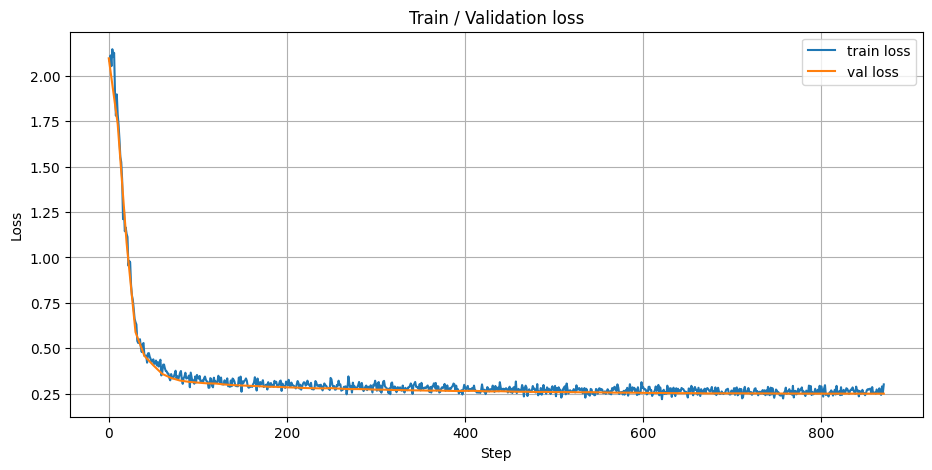

In [12]:
plt.figure(figsize=(11, 5))
plt.plot(train_logs["step"], train_logs["loss"], label="train loss")
plt.plot(eval_logs["step"], eval_logs["eval_loss"], label="val loss")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Train / Validation loss")
plt.legend()
plt.grid(True)
plt.show()

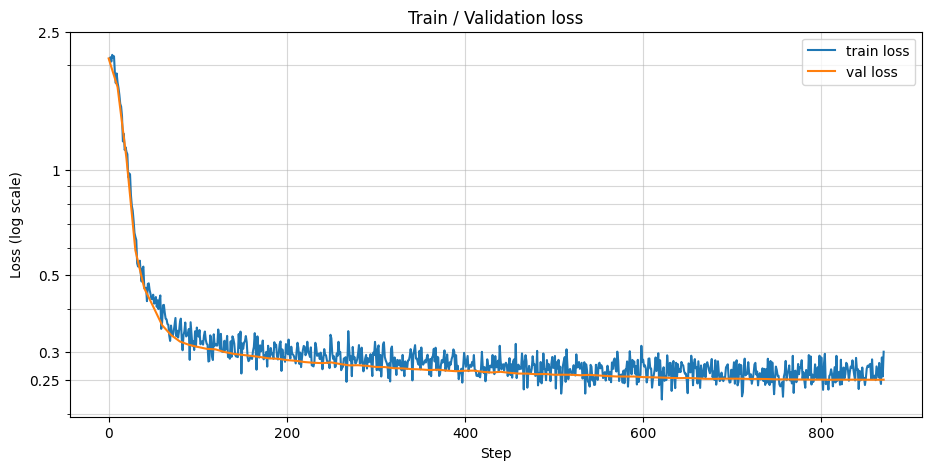

In [15]:
plt.figure(figsize=(11, 5))
plt.plot(train_logs["step"], train_logs["loss"], label="train loss")
plt.plot(eval_logs["step"], eval_logs["eval_loss"], label="val loss")
plt.yscale("log")
plt.xlabel("Step")
plt.ylabel("Loss (log scale)")
plt.title("Train / Validation loss")
yticks = [0.25, 0.3, 0.5, 1, 2.5]
plt.yticks(yticks, [str(y) for y in yticks])
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()

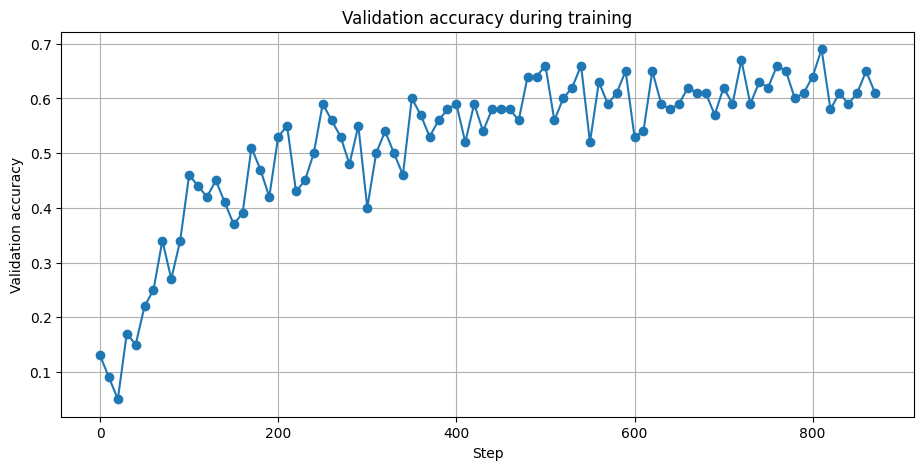

In [27]:
val_cb = None
for cb in trainer.callback_handler.callbacks:
    if isinstance(cb, ValAccuracyCallback):
        val_cb = cb
        break

val_acc_logs = pd.DataFrame(val_cb.history)

plt.figure(figsize=(11, 5))
plt.plot(val_acc_logs["step"], val_acc_logs["val_accuracy"], marker="o")
plt.xlabel("Step")
plt.ylabel("Validation accuracy")
plt.title("Validation accuracy during training")
plt.grid(True)
plt.show()

In [17]:
trainer.model.save_pretrained(output_dir)
student_tokenizer.save_pretrained(output_dir)
trainer.model.push_to_hub(hub_model_id)
student_tokenizer.push_to_hub(hub_model_id)

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

README.md: 0.00B [00:00, ?B/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

CommitInfo(commit_url='https://huggingface.co/pymlex/gemma3-1b-countdown-reasoning/commit/5636022af58433cdc2af9247ad2e4ceffb59ed20', commit_message='Upload tokenizer', commit_description='', oid='5636022af58433cdc2af9247ad2e4ceffb59ed20', pr_url=None, repo_url=RepoUrl('https://huggingface.co/pymlex/gemma3-1b-countdown-reasoning', endpoint='https://huggingface.co', repo_type='model', repo_id='pymlex/gemma3-1b-countdown-reasoning'), pr_revision=None, pr_num=None)

## Evaluation

Helper functions. We simply use the `eval` function for expression evaluation.


In [18]:
import re
import torch
from tqdm.auto import tqdm

def parse_answer(text):
    match = re.search(r"<answer>\s*(.*?)\s*</answer>", text, re.S | re.I)
    if match is None:
        return text.strip()
    return match.group(1).strip()

def split_prompt_and_target(text):
    prompt_text = re.split(r"<start_of_turn>model\s*\n", text, maxsplit=1)[0]
    match = re.search(r"equals\s+(-?\d+)\.", prompt_text)
    target = int(match.group(1))
    return prompt_text, target

def generate_student_batch_from_prompts(model, tokenizer, prompts, max_new_tokens=850):
    encodings = tokenizer(
        prompts,
        return_tensors="pt",
        padding=True
    ).to(model.device)

    print(
        f"Eval batch start | batch={len(prompts)} | "
        f"prompt_tokens={encodings['input_ids'].shape[1]} | {gpu_status_line()}"
    )

    with torch.inference_mode():
        generated = model.generate(
            **encodings,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.7,
            top_p=0.95,
            repetition_penalty=1.05,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id
        )

    prompt_lengths = encodings["attention_mask"].sum(dim=1).tolist()
    outputs = []

    for i, prompt_length in enumerate(prompt_lengths):
        completion_ids = generated[i, prompt_length:]
        completion = tokenizer.decode(completion_ids, skip_special_tokens=True).strip()
        outputs.append(completion)

    print(f"Eval batch done | {gpu_status_line()}")

    return outputs

def score_predictions(predictions, targets):
    correct = 0

    for pred, target in zip(predictions, targets):
        expr = parse_answer(pred).strip().strip("\n")
        if "=" in expr:
            expr = expr.split("=")[0].strip()

        try:
            value = eval(expr)
            if value == target:
                correct += 1
        except Exception:
            pass

    return correct, len(targets)

In [28]:
val_texts = val_ds["text"]
val_limit = min(1000, len(val_texts))

val_prompts = []
val_targets = []

for text in val_texts[:val_limit]:
    prompt_text, target = split_prompt_and_target(text)
    val_prompts.append(prompt_text)
    val_targets.append(target)

val_predictions = []
batch_prompts = []
batch_size = 200

for prompt in tqdm(val_prompts, total=len(val_prompts)):
    batch_prompts.append(prompt)

    if len(batch_prompts) == batch_size:
        completions = generate_student_batch_from_prompts(
            student_model,
            student_tokenizer,
            batch_prompts,
            max_new_tokens=850
        )
        val_predictions.extend(completions)
        batch_prompts = []

if len(batch_prompts) > 0:
    completions = generate_student_batch_from_prompts(
        student_model,
        student_tokenizer,
        batch_prompts,
        max_new_tokens=850
    )
    val_predictions.extend(completions)

correct, total = score_predictions(val_predictions, val_targets)
accuracy = correct / total
print(f"Validation accuracy: {accuracy:.4f} ({correct}/{total})")

  0%|          | 0/1000 [00:00<?, ?it/s]

Eval batch start | batch=200 | prompt_tokens=128 | GPU=0% | VRAM=31729/32607 MB
Eval batch done | GPU=93% | VRAM=31729/32607 MB
Eval batch start | batch=200 | prompt_tokens=129 | GPU=93% | VRAM=31729/32607 MB
Eval batch done | GPU=92% | VRAM=31729/32607 MB
Eval batch start | batch=200 | prompt_tokens=128 | GPU=92% | VRAM=31729/32607 MB
Eval batch done | GPU=92% | VRAM=31729/32607 MB
Eval batch start | batch=200 | prompt_tokens=128 | GPU=92% | VRAM=31729/32607 MB
Eval batch done | GPU=92% | VRAM=31729/32607 MB
Eval batch start | batch=200 | prompt_tokens=128 | GPU=92% | VRAM=31729/32607 MB
Eval batch done | GPU=92% | VRAM=31729/32607 MB
Validation accuracy: 0.8200 (820/1000)


## Inference

In [ ]:
student_tokenizer = AutoTokenizer.from_pretrained("pymlex/gemma3-1b-countdown")
if student_tokenizer.pad_token is None:
    student_tokenizer.pad_token = student_tokenizer.eos_token
student_tokenizer.padding_side = "left"

base_student_model = AutoModelForCausalLM.from_pretrained(
    student_model_id,
    device_map="auto",
    torch_dtype=torch.bfloat16 if bf16 else torch.float16
)

student_model = PeftModel.from_pretrained(base_student_model, "pymlex/gemma3-1b-countdown")
student_model.eval()

In [ ]:
def generate_student_batch(model, tokenizer, batch_messages):
    prompts = [
        tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True
        )
        for messages in batch_messages
    ]

    encodings = tokenizer(
        prompts,
        return_tensors="pt",
        padding=True
    ).to(model.device)

    print(
        f"Inference batch start | batch={len(batch_messages)} | "
        f"prompt_tokens={encodings['input_ids'].shape[1]} | {gpu_status_line()}"
    )

    with torch.inference_mode():
        generated = model.generate(
            **encodings,
            max_new_tokens=850,
            do_sample=True,
            temperature=0.7,
            top_p=0.95,
            repetition_penalty=1.05,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id
        )

    prompt_lengths = encodings["attention_mask"].sum(dim=1).tolist()
    outputs = []

    for i, prompt_length in enumerate(prompt_lengths):
        completion_ids = generated[i, prompt_length:]
        completion = tokenizer.decode(completion_ids, skip_special_tokens=True).strip()
        outputs.append(completion)

    print(f"Inference batch done | {gpu_status_line()}")

    return outputs

def parse_nums(value):
    if isinstance(value, str):
        return json.loads(value)
    return value
    

def build_test_messages_from_row(row):
    nums = parse_nums(row["nums"])
    target = row["target"]
    return [
        {
            "role": "system",
            "content": "You are a helpful assistant. You first think about the reasoning process in the mind and then provide the user with the answer."
        },
        {
            "role": "user",
            "content": f"Using the numbers {nums}, create an equation that equals {target}. You can use basic arithmetic operations (+, -, *, /) and each number can only be used once. Show your work in <think> </think> tags. And return the final equation and answer in <answer> </answer> tags, for example <answer> (1 + 2) / 3 = 1 </answer>."
        }
    ]

def predict_equations(model, tokenizer, nums_list, targets, batch_size=4, max_new_tokens=850):
    rows = [{"nums": nums, "target": target} for nums, target in zip(nums_list, targets)]
    batch_messages = []
    outputs = []

    for row in rows:
        batch_messages.append(build_test_messages_from_row(row))

        if len(batch_messages) == batch_size:
            completions = generate_student_batch(
                model,
                tokenizer,
                batch_messages
            )
            outputs.extend([parse_answer(text) for text in completions])
            batch_messages = []

    if len(batch_messages) > 0:
        completions = generate_student_batch(
            model,
            tokenizer,
            batch_messages,
            max_new_tokens
        )
        outputs.extend([parse_answer(text) for text in completions])

    return outputs

In [25]:
sample_nums = [[78, 46, 93], [24, 2, 5]]
sample_targets = [61, 31]

sample_predictions = predict_equations(
    student_model,
    student_tokenizer,
    sample_nums,
    sample_targets,
    batch_size=2,
    max_new_tokens=850
)

for pred in sample_predictions:
    print(pred)
    print('-' * 100)

Inference batch start | batch=2 | prompt_tokens=127 | GPU=0% | VRAM=31727/32607 MB
Inference batch done | GPU=77% | VRAM=31729/32607 MB
93 - (78 - 46) = 61
----------------------------------------------------------------------------------------------------
24 + 2 + 5 = 31
----------------------------------------------------------------------------------------------------
